## 1. Параметры модели

Классическая модель Лотка–Вольтерра:

\[
\dot x=\alpha x-\beta xy,\qquad
\dot y=\delta xy-\gamma y.
\]

Базовые параметры:

\[
\alpha=1.0,\quad\beta=0.1,\quad\delta=0.075,\quad\gamma=1.5.
\]

Равновесие:

\[
x^*=\frac{\gamma}{\delta}=20,\qquad
y^*=\frac{\alpha}{\beta}=10.
\]

Начальные условия задаются относительно равновесия:

\[
x_0=1.5x^*=30,\qquad y_0=0.5y^*=5.
\]

Параметр регулятора для обязательного sweep параметров модели: \(T=1.0\).

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd

# ── Параметры модели (Вариант А) ───────────────────────────────────
alpha = 1.0
beta  = 0.1
delta = 0.075
gamma = 1.5

# Равновесие
x_star = gamma / delta
y_star = alpha / beta

# ── Параметр регулятора ────────────────────────────────────────────
T = 1.0

# ── Закон управления (аддитивное по x, psi = x - x*) ──────────────
def control(x, y):
    return -(x - x_star) / T - alpha * x + beta * x * y

def rhs_closed(t, state):
    x, y = state
    u = control(x, y)
    return [alpha*x - beta*x*y + u, delta*x*y - gamma*y]

# ── Начальные условия и время ──────────────────────────────────────
x0, y0 = x_star * 1.5, y_star * 0.5
t_span = (0, 100)
t_eval = np.linspace(*t_span, 10000)

# ── Метрики качества ───────────────────────────────────────────────
def compute_metrics(sol, x_star, control_function):
    """Четыре метрики из условия задания."""
    if not sol.success:
        return dict(tau=None, max_psi=np.inf, max_u=np.inf, e_final=np.inf)

    x_sol = sol.y[0]
    y_sol = sol.y[1]
    t_sol = sol.t

    psi = x_sol - x_star
    psi_0 = abs(psi[0])
    threshold = 0.01 * psi_0

    tau = None
    for i in range(len(t_sol)):
        if abs(psi[i]) < threshold:
            tau = t_sol[i]
            break

    u_sol = np.array([
        control_function(x, y) for x, y in zip(x_sol, y_sol)
    ])

    return dict(
        tau=tau,
        max_psi=np.max(np.abs(psi)),
        max_u=np.max(np.abs(u_sol)),
        e_final=abs(x_sol[-1] - x_star)
    )

# ── Базовое решение ────────────────────────────────────────────────
sol_base = solve_ivp(
    rhs_closed, t_span, [x0, y0],
    t_eval=t_eval, method='RK45', rtol=1e-8
)

metrics_base = compute_metrics(sol_base, x_star, control)

print(f"x* = {x_star:.4f}")
print(f"y* = {y_star:.4f}")
print("Базовые метрики:")
for k, v in metrics_base.items():
    print(f"  {k}: {v:.6g}" if v is not None else f"  {k}: не достигнуто")

x* = 20.0000
y* = 10.0000
Базовые метрики:
  tau: 4.61046
  max_psi: 10
  max_u: 25
  e_final: 3.09837e-07


## 2. 1D sweep по каждому параметру

При каждом значении меняется только один параметр, остальные фиксируются на базовых значениях. Равновесие \((x^*,y^*)\) и начальные условия пересчитываются для каждой точки.

Диапазоны:
- \(\alpha\): [0.5, 2.0], 10 точек;
- \(\beta\): [0.05, 0.20], 10 точек;
- \(\delta\): [0.04, 0.15], 10 точек;
- \(\gamma\): [0.5, 3.0], 10 точек.

In [2]:
# ── Универсальный sweep в стиле skeleton ───────────────────────────
base_params = {
    'alpha': alpha,
    'beta': beta,
    'delta': delta,
    'gamma': gamma
}

sweep_values = {
    'alpha': np.linspace(0.5, 2.0, 10),
    'beta':  np.linspace(0.05, 0.20, 10),
    'delta': np.linspace(0.04, 0.15, 10),
    'gamma': np.linspace(0.5, 3.0, 10)
}

def run_parameter_sweep(parameter, values, T_value=1.0):
    records = []

    for value in values:
        p = base_params.copy()
        p[parameter] = float(value)

        a = p['alpha']
        b = p['beta']
        d = p['delta']
        g = p['gamma']

        # Равновесие варианта А
        x_s = g / d
        y_s = a / b

        # Начальные условия
        initial = [1.5 * x_s, 0.5 * y_s]

        # Закон управления для текущего набора параметров
        def ctrl(x, y, a_=a, b_=b, xs=x_s, T_=T_value):
            return -(x - xs) / T_ - a_ * x + b_ * x * y

        def rhs(t, z, a_=a, b_=b, d_=d, g_=g):
            x, y = z
            u = ctrl(x, y)
            return [
                a_ * x - b_ * x * y + u,
                d_ * x * y - g_ * y
            ]

        sol = solve_ivp(
            rhs, t_span, initial,
            t_eval=t_eval, method='RK45', rtol=1e-8
        )

        m = compute_metrics(sol, x_s, ctrl)

        records.append({
            parameter: float(value),
            'x*': x_s,
            'y*': y_s,
            'tau': m['tau'],
            'max_psi': m['max_psi'],
            'max_u': m['max_u'],
            'e_final': m['e_final']
        })

    return pd.DataFrame(records)


def plot_sweep(df, parameter):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(
        f'1D sweep: влияние параметра {parameter} (T=1.0)',
        fontsize=13
    )

    plots = [
        ('tau', 'Время сходимости τ'),
        ('max_psi', 'Максимальное отклонение max|ψ|'),
        ('max_u', 'Максимальное управление max|u|'),
        ('e_final', 'Остаточная ошибка e_final')
    ]

    for ax, (column, title) in zip(axes.flatten(), plots):
        ax.plot(df[parameter], df[column], 'o-', linewidth=1.5)
        ax.set_xlabel(parameter)
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

1D sweep по alpha:


,alpha,x*,y*,tau,max_psi,max_u,e_final
0,0.500000,20.0,5.000000,4.610461,10.0,17.5,0.000000
1,0.666667,20.0,6.666667,4.610461,10.0,20.0,0.000001
2,0.833333,20.0,8.333333,4.610461,10.0,22.5,0.000000
3,1.000000,20.0,10.000000,4.610461,10.0,25.0,0.000000
4,1.166667,20.0,11.666667,4.610461,10.0,27.5,0.000000
5,1.333333,20.0,13.333333,4.610461,10.0,30.0,0.000000
6,1.500000,20.0,15.000000,4.610461,10.0,32.5,0.000001
7,1.666667,20.0,16.666667,4.610461,10.0,35.0,0.000000
8,1.833333,20.0,18.333333,4.610461,10.0,37.5,0.000000
9,2.000000,20.0,20.000000,4.610461,10.0,40.0,0.000000


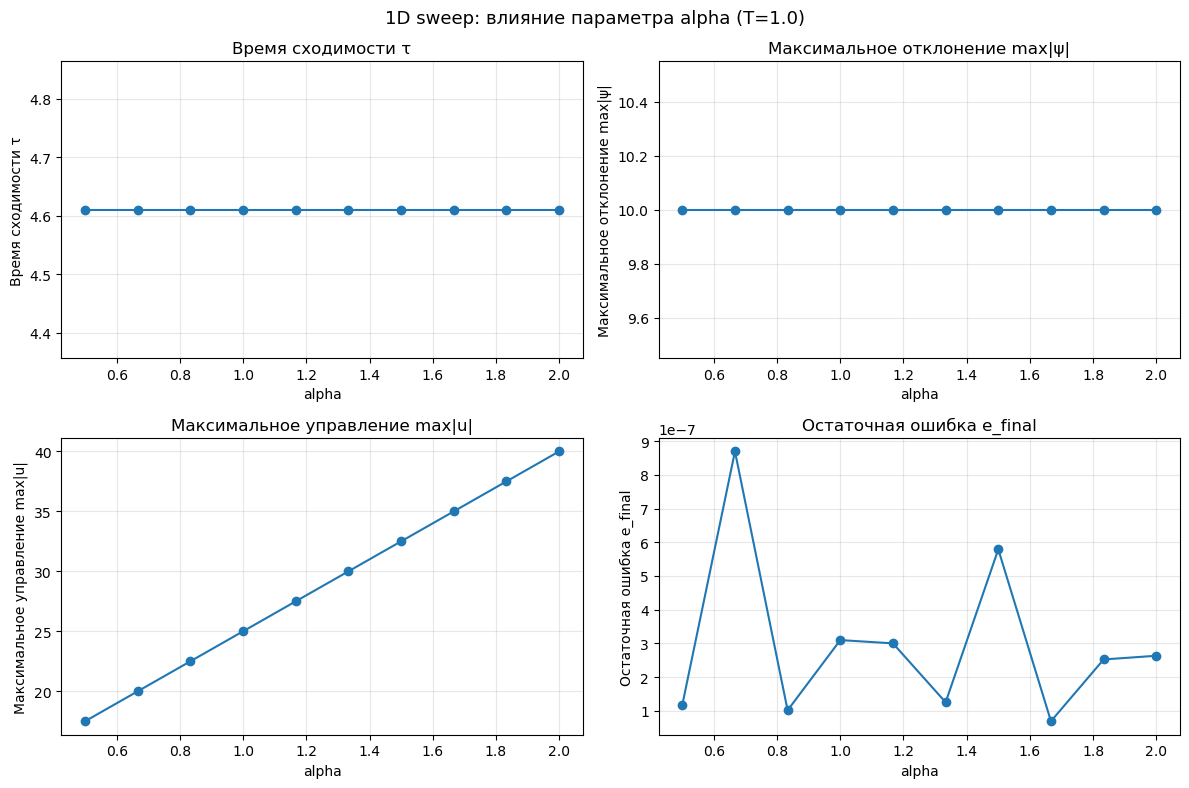

In [3]:
# ── Sweep по alpha ─────────────────────────────────────────────────
df_alpha = run_parameter_sweep('alpha', sweep_values['alpha'], T)
print('1D sweep по alpha:')
display(df_alpha.round(6))
plot_sweep(df_alpha, 'alpha')

1D sweep по beta:


,beta,x*,y*,tau,max_psi,max_u,e_final
0,0.050000,20.0,20.000000,4.610461,10.0,25.0,0.000000
1,0.066667,20.0,15.000000,4.610461,10.0,25.0,0.000001
2,0.083333,20.0,12.000000,4.610461,10.0,25.0,0.000000
3,0.100000,20.0,10.000000,4.610461,10.0,25.0,0.000000
4,0.116667,20.0,8.571429,4.610461,10.0,25.0,0.000000
5,0.133333,20.0,7.500000,4.610461,10.0,25.0,0.000001
6,0.150000,20.0,6.666667,4.610461,10.0,25.0,0.000001
7,0.166667,20.0,6.000000,4.610461,10.0,25.0,0.000000
8,0.183333,20.0,5.454545,4.610461,10.0,25.0,0.000000
9,0.200000,20.0,5.000000,4.610461,10.0,25.0,0.000000


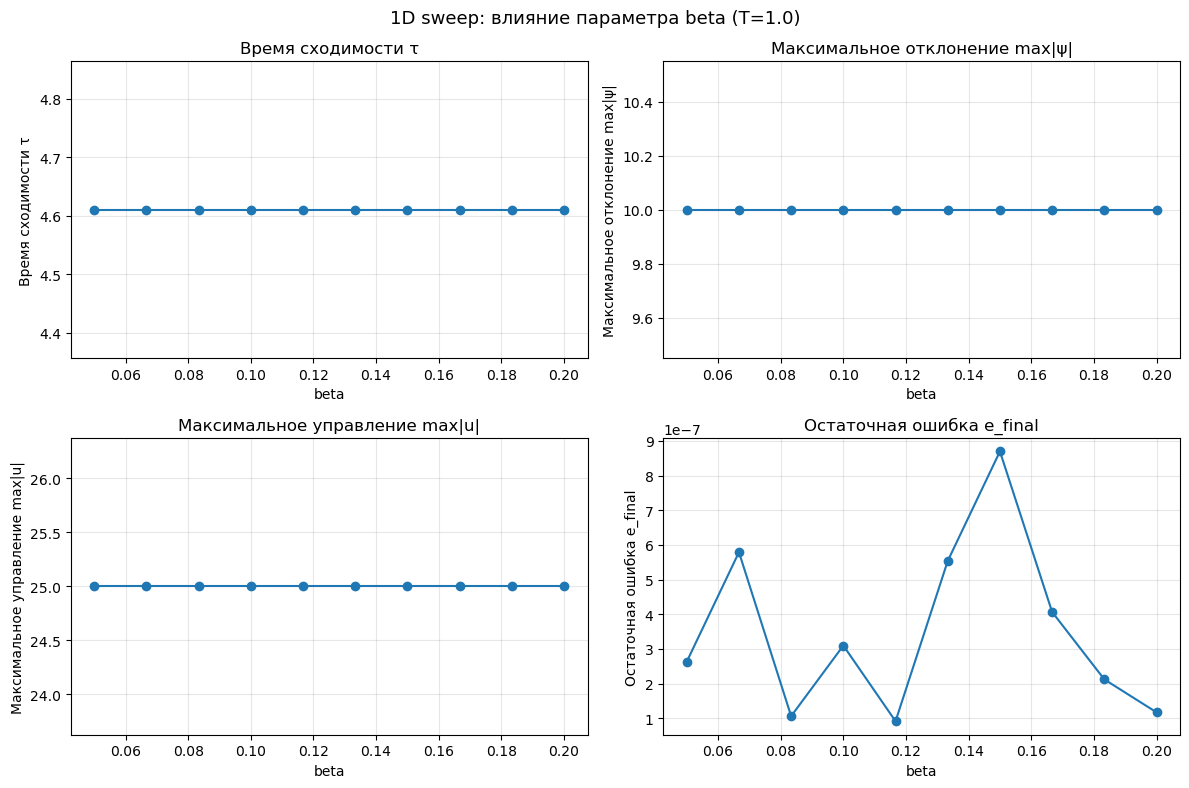

In [4]:
# ── Sweep по beta ──────────────────────────────────────────────────
df_beta = run_parameter_sweep('beta', sweep_values['beta'], T)
print('1D sweep по beta:')
display(df_beta.round(6))
plot_sweep(df_beta, 'beta')

1D sweep по delta:


,delta,x*,y*,tau,max_psi,max_u,e_final
0,0.040000,37.500000,10.0,4.610461,18.750000,46.875000,0.000001
1,0.052222,28.723404,10.0,4.610461,14.361702,35.904255,0.000001
2,0.064444,23.275862,10.0,4.610461,11.637931,29.094828,0.000001
3,0.076667,19.565217,10.0,4.610461,9.782609,24.456522,0.000000
4,0.088889,16.875000,10.0,4.610461,8.437500,21.093750,0.000000
5,0.101111,14.835165,10.0,4.610461,7.417582,18.543956,0.000001
6,0.113333,13.235294,10.0,4.610461,6.617647,16.544118,0.000000
7,0.125556,11.946903,10.0,4.610461,5.973451,14.933628,0.000000
8,0.137778,10.887097,10.0,4.610461,5.443548,13.608871,0.000000
9,0.150000,10.000000,10.0,4.610461,5.000000,12.500000,0.000000


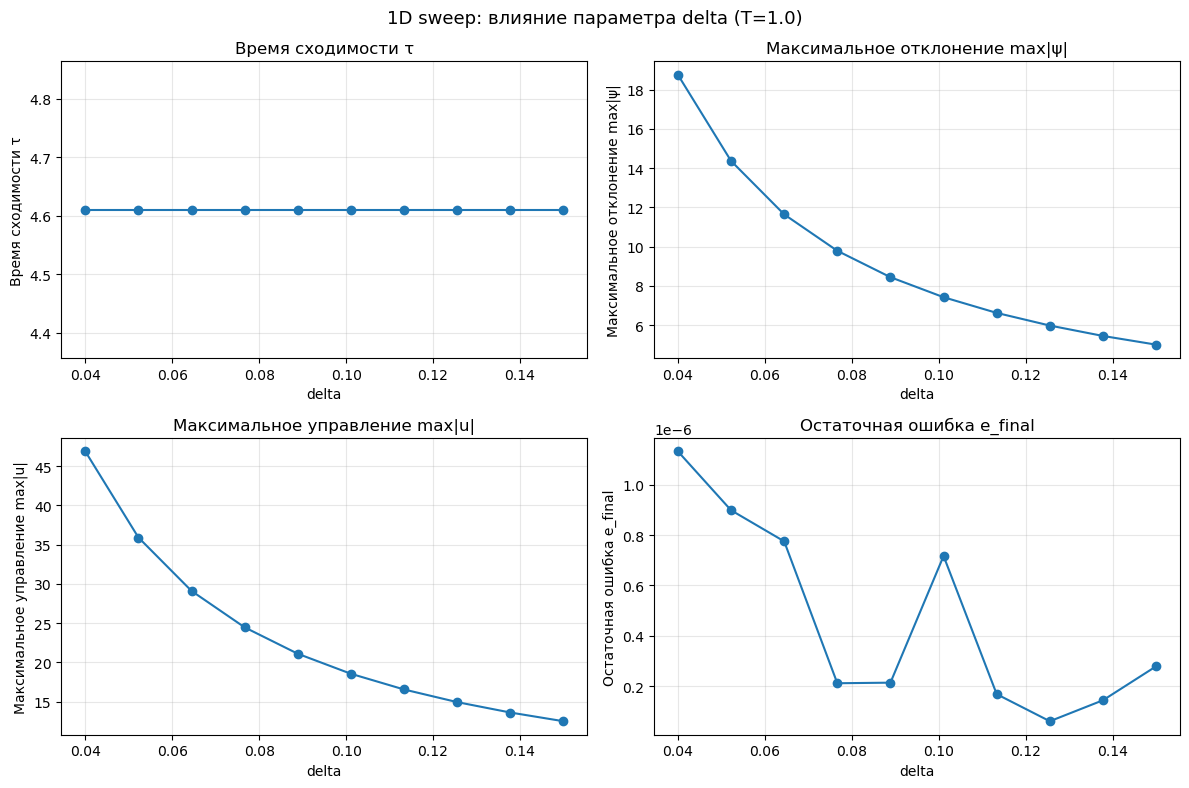

In [5]:
# ── Sweep по delta ─────────────────────────────────────────────────
df_delta = run_parameter_sweep('delta', sweep_values['delta'], T)
print('1D sweep по delta:')
display(df_delta.round(6))
plot_sweep(df_delta, 'delta')

1D sweep по gamma:


,gamma,x*,y*,tau,max_psi,max_u,e_final
0,0.500000,6.666667,10.0,4.610461,3.333333,8.333333,0.000000
1,0.777778,10.370370,10.0,4.610461,5.185185,12.962963,0.000000
2,1.055556,14.074074,10.0,4.610461,7.037037,17.592593,0.000000
3,1.333333,17.777778,10.0,4.610461,8.888889,22.222222,0.000001
4,1.611111,21.481481,10.0,4.610461,10.740741,26.851852,0.000000
5,1.888889,25.185185,10.0,4.610461,12.592593,31.481481,0.000000
6,2.166667,28.888889,10.0,4.610461,14.444444,36.111111,0.000000
7,2.444444,32.592593,10.0,4.610461,16.296296,40.740741,0.000000
8,2.722222,36.296296,10.0,4.610461,18.148148,45.370370,0.000001
9,3.000000,40.000000,10.0,4.610461,20.000000,50.000000,0.000000


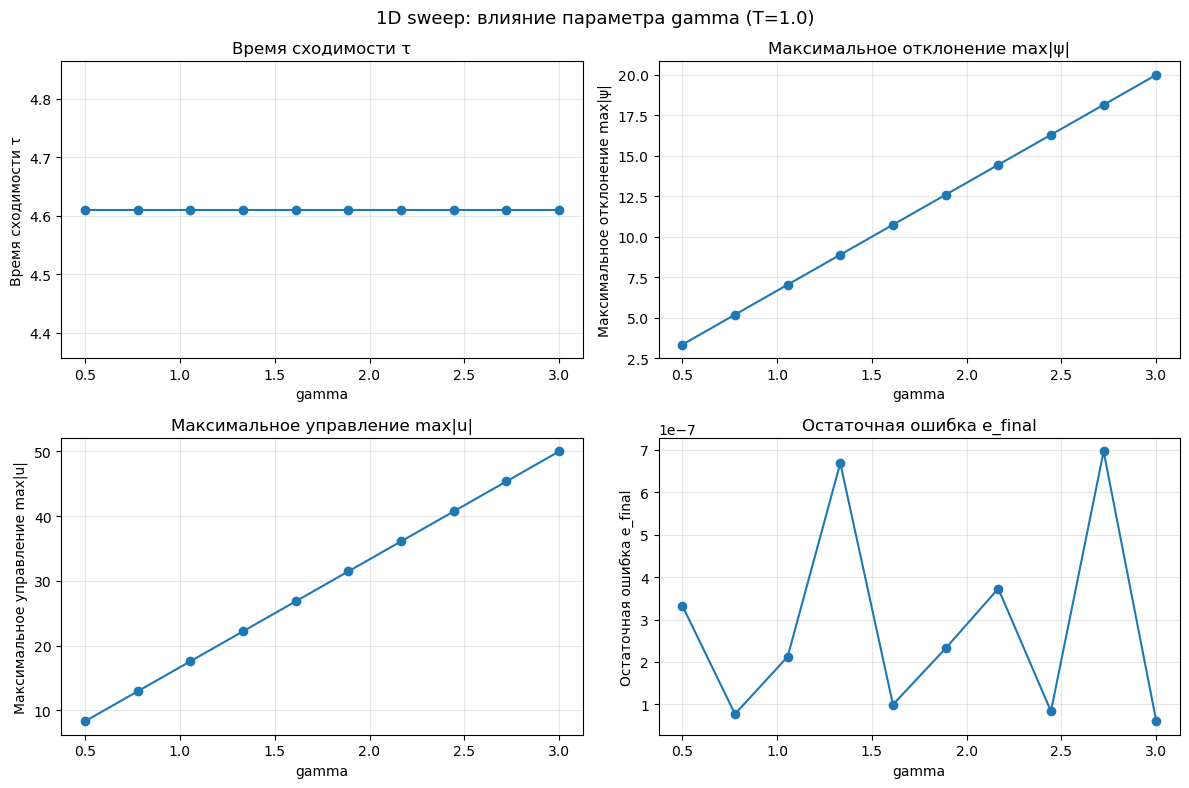

In [6]:
# ── Sweep по gamma ─────────────────────────────────────────────────
df_gamma = run_parameter_sweep('gamma', sweep_values['gamma'], T)
print('1D sweep по gamma:')
display(df_gamma.round(6))
plot_sweep(df_gamma, 'gamma')

## 3. Наблюдения по 1D sweep

При изменении параметров модель каждый раз получает новое равновесие, поэтому сравнивать нужно не только сами значения \(x,y\), но и метрики качества управления.

- При изменении \(\alpha\) меняется \(y^*=\alpha/\beta\).
- При изменении \(\beta\) меняется \(y^*=\alpha/\beta\).
- При изменении \(\delta\) меняется \(x^*=\gamma/\delta\).
- При изменении \(\gamma\) меняется \(x^*=\gamma/\delta\).

При фиксированном \(T=1\) АКАР задаёт одну и ту же желаемую скорость затухания \(\psi\), поэтому время сходимости определяется прежде всего \(T\), а величина управления зависит от конкретных параметров модели.

## 4. Sweep по параметру регулятора \(T\)

Для варианта 6А дополнительно исследуется

\[
T\in[0.2,5.0]
\]

на 15 точках при базовых параметрах модели.

In [7]:
# ── Sweep по T ─────────────────────────────────────────────────────
T_values = np.linspace(0.2, 5.0, 15)
records_T = []

for T_current in T_values:

    # Базовые параметры и базовое равновесие
    x_s = gamma / delta
    y_s = alpha / beta

    def ctrl_T(x, y, T_=T_current):
        return -(x - x_s) / T_ - alpha*x + beta*x*y

    def rhs_T(t, z):
        x, y = z
        u = ctrl_T(x, y)
        return [
            alpha*x - beta*x*y + u,
            delta*x*y - gamma*y
        ]

    sol = solve_ivp(
        rhs_T, t_span, [1.5*x_s, 0.5*y_s],
        t_eval=t_eval, method='RK45', rtol=1e-8
    )

    m = compute_metrics(sol, x_s, ctrl_T)

    records_T.append({
        'T': T_current,
        'tau': m['tau'],
        'max_psi': m['max_psi'],
        'max_u': m['max_u'],
        'e_final': m['e_final']
    })

df_T = pd.DataFrame(records_T)

print('Sweep по T:')
display(df_T.round(6))

Sweep по T:


,T,tau,max_psi,max_u,e_final
0,0.200000,0.930093,10.0,65.000000,0.0
1,0.542857,2.500250,10.0,33.421053,0.0
2,0.885714,4.080408,10.0,26.290323,0.0
3,1.228571,5.660566,10.0,23.139535,0.0
4,1.571429,7.240724,10.0,21.363636,0.0
5,1.914286,8.820882,10.0,22.026462,0.0
6,2.257143,10.401040,10.0,34.349876,0.0
7,2.600000,11.981198,10.0,50.286881,0.0
8,2.942857,13.561356,10.0,70.897094,0.0
9,3.285714,15.131513,10.0,97.550835,0.0


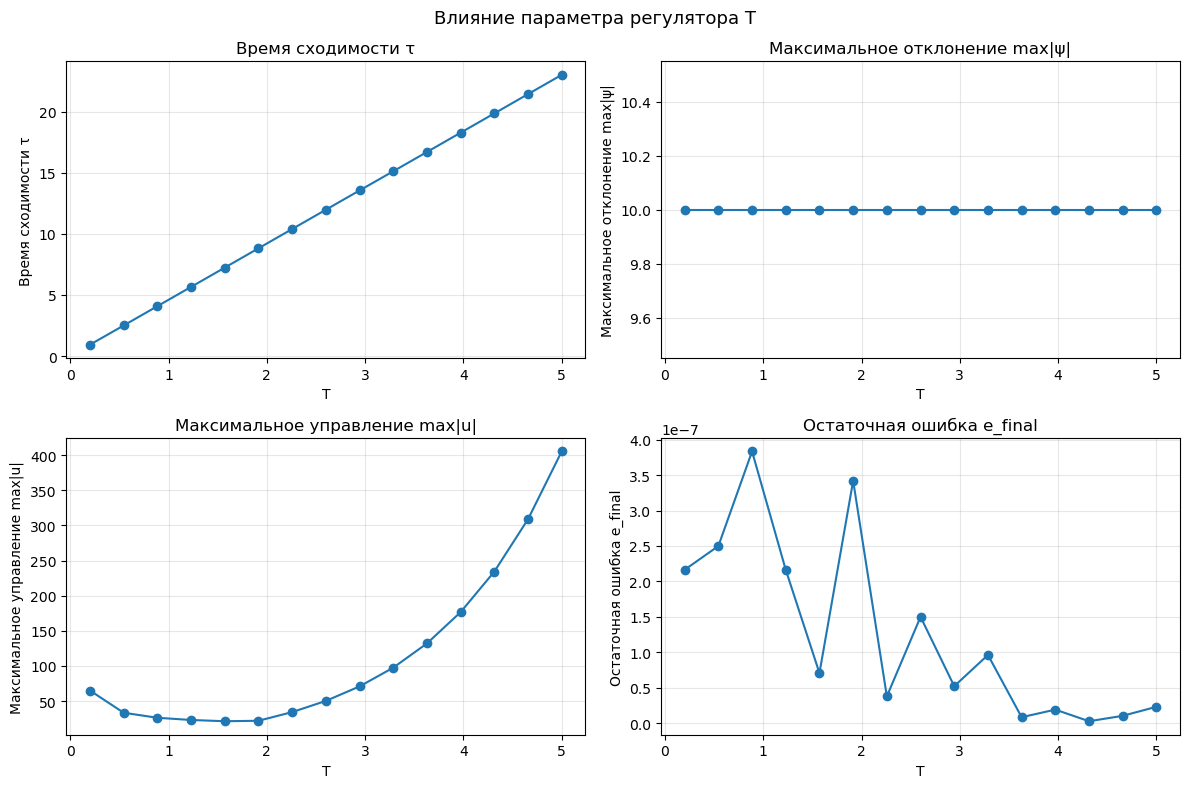

Оптимальное T по каждой метрике:
  tau: T = 0.2000, значение = 0.93009301
  max_psi: T = 0.2000, значение = 10
  max_u: T = 1.5714, значение = 21.363636
  e_final: T = 4.3143, значение = 2.6521718e-09


In [8]:
# ── Графики метрик vs T ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Влияние параметра регулятора T', fontsize=13)

plots = [
    ('tau', 'Время сходимости τ'),
    ('max_psi', 'Максимальное отклонение max|ψ|'),
    ('max_u', 'Максимальное управление max|u|'),
    ('e_final', 'Остаточная ошибка e_final')
]

for ax, (column, title) in zip(axes.flatten(), plots):
    ax.plot(df_T['T'], df_T[column], 'o-', linewidth=1.5)
    ax.set_xlabel('T')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Оптимальное T по каждой метрике:')
for column in ['tau', 'max_psi', 'max_u', 'e_final']:
    valid = df_T[column].notna() & np.isfinite(df_T[column].astype(float))
    if valid.any():
        idx = df_T.loc[valid, column].astype(float).idxmin()
        print(
            f"  {column}: T = {df_T.loc[idx, 'T']:.4f}, "
            f"значение = {df_T.loc[idx, column]:.8g}"
        )
    else:
        print(f"  {column}: нет допустимых значений")

### Вывод по sweep по \(T\)

Поскольку

\[
\dot\psi=-\frac{\psi}{T},
\]

меньшее \(T\) соответствует более быстрому затуханию макропеременной. При увеличении \(T\) система приходит к цели медленнее.

Таким образом, \(T\) является параметром быстродействия регулятора. Выбор \(T\) — компромисс между скоростью сходимости и интенсивностью управляющего воздействия.

## 5. Сравнение с поведением без управления

Для базовых параметров решается система без управления, то есть \(u=0\). Затем на одном графике сравнивается \(x(t)\) без управления и \(x(t)\) с АКАР при \(T=1.0\).

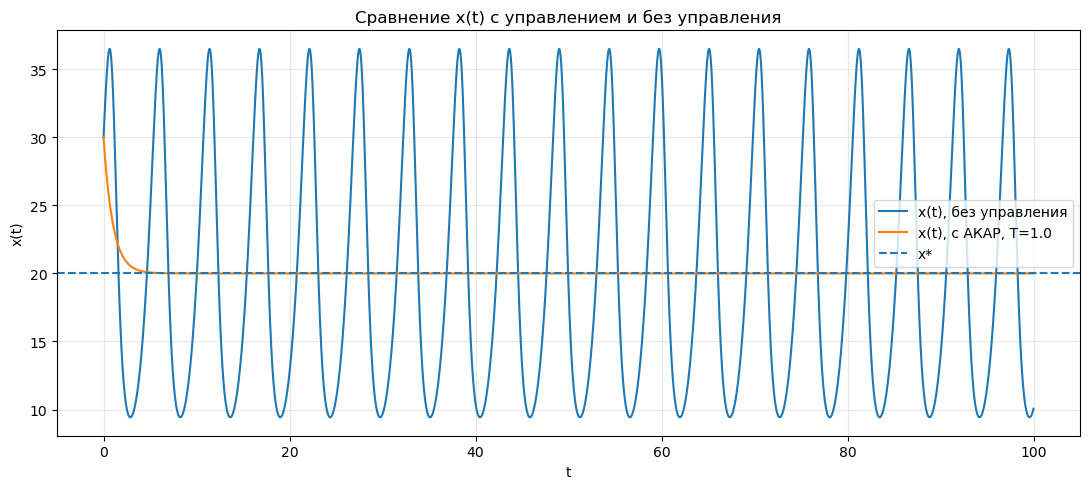

In [9]:
# ── Система без управления ─────────────────────────────────────────
def rhs_open(t, state):
    x, y = state
    return [
        alpha*x - beta*x*y,
        delta*x*y - gamma*y
    ]

sol_open = solve_ivp(
    rhs_open, t_span, [x0, y0],
    t_eval=t_eval, method='RK45', rtol=1e-8
)

# ── Система с управлением при T=1.0 ────────────────────────────────
T = 1.0
sol_controlled = solve_ivp(
    rhs_closed, t_span, [x0, y0],
    t_eval=t_eval, method='RK45', rtol=1e-8
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sol_open.t, sol_open.y[0], label='x(t), без управления')
ax.plot(sol_controlled.t, sol_controlled.y[0], label='x(t), с АКАР, T=1.0')
ax.axhline(x_star, linestyle='--', label='x*')
ax.set_xlabel('t')
ax.set_ylabel('x(t)')
ax.set_title('Сравнение x(t) с управлением и без управления')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Комментарий к сравнению

Без управления \(u=0\) система следует собственной динамике модели Лотка–Вольтерра, для которой характерны колебания численности жертв и хищников.

При включении АКАР макропеременная


\psi=x-x^*
\]

направляется к нулю. Поэтому \(x(t)\) приближается к заданному уровню \(x^*=20\).

Следовательно, АКАР изменяет естественную динамику системы так, чтобы выбранная переменная достигла целевого состояния.

# 6. Итоговые выводы

В работе исследована классическая модель Лотка–Вольтерра с АКАР-управлением.

- проведён 1D sweep по \(\alpha,\beta,\delta,\gamma\);
- для каждой точки пересчитано равновесие;
- рассчитаны четыре метрики качества;
- построены графики метрик;
- проведён sweep по \(T\) на 15 точках в диапазоне [0.2, 5.0];
- определены минимальные значения \(T\) по метрикам;
- выполнено сравнение \(x(t)\) с управлением и без управления.

Главный результат: уменьшение \(T\) ускоряет сходимость макропеременной \(\psi\), а увеличение \(T\) делает управление более медленным. АКАР позволяет направить \(x(t)\) к целевому равновесию \(x^*\).